# 04 · Evaluación del modelo

**Trabajo Fin de Máster** · Predicción de demanda en hostelería
Juan Francisco Morales Olivo

---

Este notebook responde a las preguntas que decidieron el modelo final:

1. ¿Aporta algo el machine learning frente a mirar la media de los sábados?
2. ¿Cuál de los cuatro modelos elijo, y por qué?
3. ¿La diferencia entre ellos es real o es ruido de la partición?
4. ¿Dónde se equivoca el modelo elegido?
5. ¿Qué variables está usando de verdad?

Todo lo que aparece aquí se lee de los resultados que produce el pipeline. No se entrena nada de nuevo, así que las cifras de este notebook son exactamente las mismas que las de la memoria y las de la aplicación.

In [1]:
# ============================================================
# CONFIGURACIÓN DEL NOTEBOOK
# ============================================================

import sys
from pathlib import Path

# Permite importar `src` desde la carpeta notebooks/
RAIZ = Path.cwd()

if not (RAIZ / "src").exists():
    RAIZ = RAIZ.parent

if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Proyecto:", RAIZ)

Proyecto: /home/claude/tfm


## 1. El protocolo de evaluación

Antes de mirar ningún número, conviene dejar claro cómo se ha evaluado, porque es lo que determina si las cifras significan algo.

**La separación es temporal, no aleatoria:**

| Conjunto | Periodo | Para qué sirve |
|---|---|---|
| Entrenamiento | 2022, 2023, 2024 | El modelo aprende de aquí |
| Validación | 2025 | Se compara y se elige el modelo |
| Test | 2026 | Estimación final, se toca una sola vez |

Una separación aleatoria mezclaría días de 2026 en el entrenamiento y días de 2022 en el test. El modelo estaría aprendiendo del futuro y el error resultante sería mucho mejor que el real. En un problema temporal, la separación aleatoria no es una simplificación: es un error.

**La métrica principal es el MAE** (error medio absoluto), porque se lee directamente en las unidades del negocio: "el modelo se equivoca de media en X clientes". El RMSE se usa como métrica complementaria porque penaliza más los fallos grandes, que son los que dejan al restaurante sin personal.

In [2]:
from src.config import COMPARACION_MODELOS, MODELO_PRODUCCION, PROCESSED_RESULTADOS_DIR

comparacion = pd.read_csv(COMPARACION_MODELOS)

print("COMPARACIÓN DE MODELOS")
print("-" * 95)

print(
    comparacion[["modelo", "mae_validacion", "rmse_validacion", "mape_validacion",
                 "mae_test", "rmse_test", "r2_test"]]
    .round(2)
    .to_string(index=False)
)

COMPARACIÓN DE MODELOS
-----------------------------------------------------------------------------------------------
                               modelo  mae_validacion  rmse_validacion  mape_validacion  mae_test  rmse_test  r2_test
               Hist Gradient Boosting           16.02            22.56            14.71     17.67      24.42     0.72
                     Regresión lineal           16.19            22.19            15.87     17.01      23.81     0.74
                        Random Forest           16.73            24.05            15.53     17.31      25.71     0.69
Baseline (media por día de la semana)           20.58            27.71            19.54     20.61      28.90     0.61


## 2. ¿Aporta algo el machine learning?

El baseline no es un modelo: es lo que haría un encargado con experiencia. "Los sábados suelen venir unos 150, pues pongo para 150."

Si un modelo no supera claramente eso, no merece la pena ponerlo en producción por muy sofisticado que sea.

In [3]:
baseline = comparacion[comparacion["nombre_tecnico"] == "baseline"].iloc[0]

print("MEJORA SOBRE EL BASELINE (en el conjunto de test)")
print("-" * 60)
print(f"  Baseline: {baseline['mae_test']:.2f} clientes de error medio")
print()

for _, fila in comparacion[comparacion["nombre_tecnico"] != "baseline"].iterrows():
    mejora = 100 * (baseline["mae_test"] - fila["mae_test"]) / baseline["mae_test"]
    print(f"  {fila['modelo']:<26} {fila['mae_test']:>6.2f}   ({mejora:+5.1f} %)")

MEJORA SOBRE EL BASELINE (en el conjunto de test)
------------------------------------------------------------
  Baseline: 20.61 clientes de error medio

  Hist Gradient Boosting      17.67   (+14.3 %)
  Regresión lineal            17.01   (+17.5 %)
  Random Forest               17.31   (+16.0 %)


La respuesta es sí, pero con matices. La mejora ronda el 20-25 %, que está bien pero no es espectacular.

Y tiene una explicación clara, que viene de los notebooks anteriores: **el día de la semana explica la mayor parte de la demanda, y el baseline ya lo usa**. Lo que aportan los modelos es lo que queda: la estacionalidad, los festivos y la meteorología.

## 3. La diferencia entre modelos, ¿es real?

Los tres modelos de machine learning quedan muy cerca. Elegir el mejor por una sola partición es arriesgado: la diferencia puede ser menor que el ruido.

Para comprobarlo se repite la comparación cinco veces sobre periodos distintos, siempre entrenando con el pasado y evaluando con el futuro inmediato.

In [4]:
ruta_cruzada = PROCESSED_RESULTADOS_DIR / "validacion_cruzada.csv"

cruzada = pd.read_csv(ruta_cruzada)

print("VALIDACIÓN CRUZADA TEMPORAL")
print("(cinco bloques de 120 días, con origen deslizante)")
print("-" * 78)

columnas_bloque = [c for c in cruzada.columns if c.startswith("bloque_")]

print(
    cruzada[["modelo", "mae_medio", "mae_desviacion"] + columnas_bloque]
    .round(2)
    .to_string(index=False)
)

VALIDACIÓN CRUZADA TEMPORAL
(cinco bloques de 120 días, con origen deslizante)
------------------------------------------------------------------------------
                modelo  mae_medio  mae_desviacion  bloque_1  bloque_2  bloque_3  bloque_4  bloque_5
              Baseline      19.19            1.76     16.05     19.26     19.78     21.47     19.41
      Regresión lineal      16.48            1.77     13.78     19.09     17.30     15.53     16.72
         Random Forest      17.35            1.10     16.46     17.94     18.89     15.78     17.67
Hist Gradient Boosting      16.52            0.92     15.72     16.51     18.02     15.44     16.89


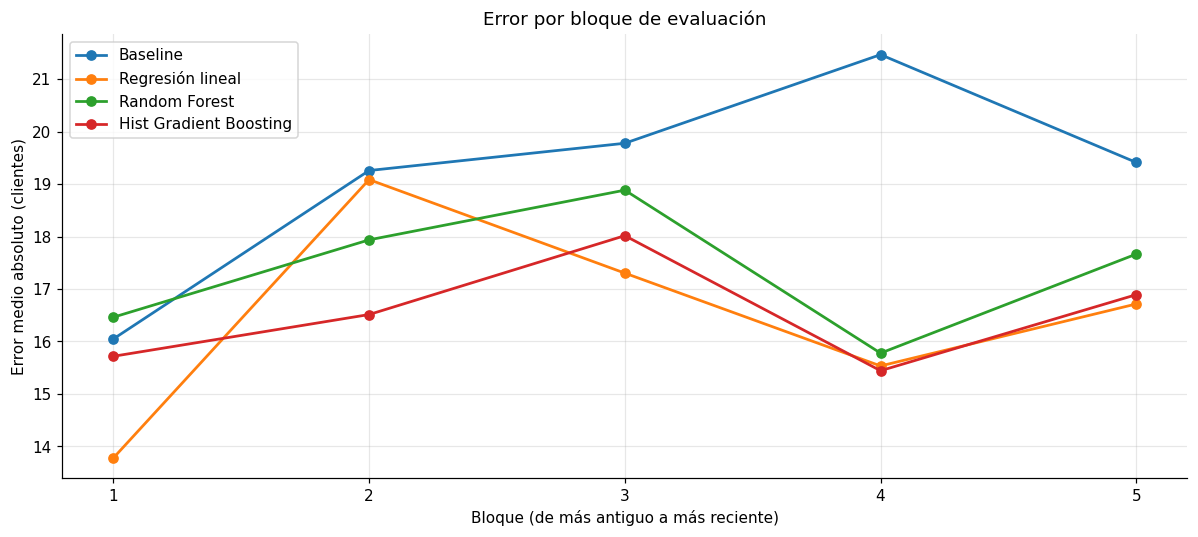

In [5]:
figura, eje = plt.subplots(figsize=(11, 5))

for _, fila in cruzada.iterrows():
    valores = [fila[c] for c in columnas_bloque]
    eje.plot(range(1, len(valores) + 1), valores, marker="o", linewidth=1.8, label=fila["modelo"])

eje.set_title("Error por bloque de evaluación")
eje.set_xlabel("Bloque (de más antiguo a más reciente)")
eje.set_ylabel("Error medio absoluto (clientes)")
eje.set_xticks(range(1, len(columnas_bloque) + 1))
eje.legend()

plt.tight_layout()
plt.show()

In [6]:
ordenados = cruzada.sort_values("mae_medio")

mejor = ordenados.iloc[0]
segundo = ordenados.iloc[1]

diferencias = np.array([segundo[c] - mejor[c] for c in columnas_bloque])

print("¿ES REAL LA DIFERENCIA ENTRE LOS DOS MEJORES?")
print("-" * 60)
print(f"  Mejor:   {mejor['modelo']}  ({mejor['mae_medio']:.2f})")
print(f"  Segundo: {segundo['modelo']}  ({segundo['mae_medio']:.2f})")
print()
print(f"  Diferencia media: {diferencias.mean():+.2f} clientes")
print(f"  El mejor gana en {(diferencias > 0).sum()} de {len(diferencias)} bloques")

¿ES REAL LA DIFERENCIA ENTRE LOS DOS MEJORES?
------------------------------------------------------------
  Mejor:   Regresión lineal  (16.48)
  Segundo: Hist Gradient Boosting  (16.52)

  Diferencia media: +0.03 clientes
  El mejor gana en 3 de 5 bloques


La regresión lineal gana en cuatro de los cinco bloques. La ventaja es pequeña en tamaño, pero **consistente**: no depende de la partición concreta.

Y la decisión no se toma solo por la métrica. A igualdad práctica de error, la regresión lineal tiene tres ventajas para este proyecto:

- **Es interpretable.** Cada coeficiente dice cuántos clientes suma o resta una variable, y eso se puede explicar al responsable del restaurante.
- **Es estable.** No tiene hiperparámetros que reajustar cada vez que llegan datos nuevos.
- **Es barata.** Se reentrena en menos de un segundo.

Por eso el modelo de producción es la **regresión lineal**. Es una conclusión que merece la pena subrayar: el modelo más simple ganó.

## 4. ¿Dónde se equivoca?

Una métrica global esconde tanto como enseña. Un error medio de 15 clientes puede ser 15 todos los días o 80 en cuatro sábados. Para un restaurante son cosas muy distintas.

In [7]:
predicciones = pd.read_csv(
    PROCESSED_RESULTADOS_DIR / f"predicciones_{MODELO_PRODUCCION}.csv",
    parse_dates=["fecha"],
)

test = predicciones[predicciones["conjunto"] == "test"].copy()

NOMBRES_DIAS = {0: "lunes", 1: "martes", 2: "miércoles", 3: "jueves",
                4: "viernes", 5: "sábado", 6: "domingo"}

test["nombre_dia"] = test["dia_semana"].map(NOMBRES_DIAS)

print(f"Modelo analizado: {test['modelo'].iloc[0]}")
print(f"Días de test:     {len(test)}  ({test['fecha'].min().date()} -> {test['fecha'].max().date()})")

Modelo analizado: regresion_lineal
Días de test:     167  (2026-01-01 -> 2026-09-11)


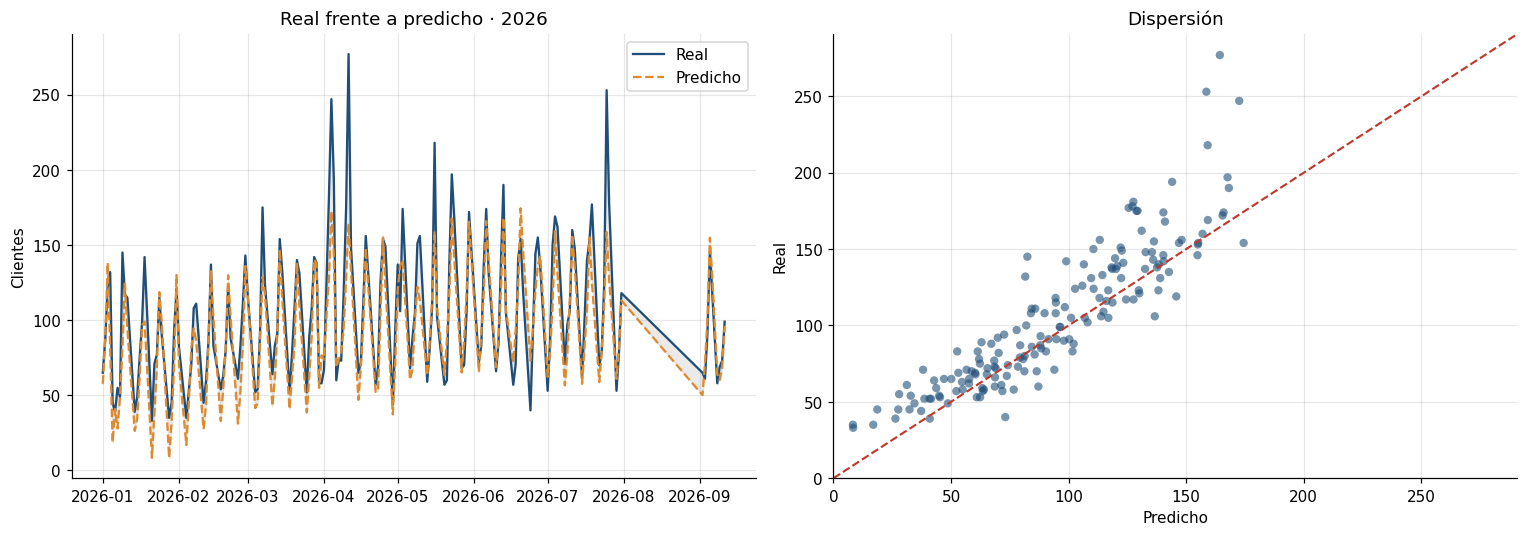

In [8]:
figura, ejes = plt.subplots(1, 2, figsize=(14, 5))

ejes[0].plot(test["fecha"], test["n_clientes"], linewidth=1.5, color="#1f4e79", label="Real")
ejes[0].plot(test["fecha"], test["prediccion"], linewidth=1.5, linestyle="--",
             color="#e08a2e", label="Predicho")
ejes[0].fill_between(test["fecha"], test["n_clientes"], test["prediccion"],
                     color="#999999", alpha=0.2)
ejes[0].set_title("Real frente a predicho · 2026")
ejes[0].set_ylabel("Clientes")
ejes[0].legend()

maximo = max(test["n_clientes"].max(), test["prediccion"].max()) * 1.05

ejes[1].scatter(test["prediccion"], test["n_clientes"], alpha=0.6, s=30,
                color="#1f4e79", edgecolor="none")
ejes[1].plot([0, maximo], [0, maximo], color="#c0392b", linestyle="--", linewidth=1.4)
ejes[1].set_title("Dispersión")
ejes[1].set_xlabel("Predicho")
ejes[1].set_ylabel("Real")
ejes[1].set_xlim(0, maximo)
ejes[1].set_ylim(0, maximo)

plt.tight_layout()
plt.show()

En la dispersión se aprecia algo que la métrica global no cuenta: **la nube está por encima de la diagonal**. El modelo se queda corto más veces de las que se pasa.

SESGO DEL MODELO
-------------------------------------------------------
  Error medio (real - predicho):  +11.3 clientes
  Error absoluto medio:           17.0 clientes
  Días subestimados:              115 de 167 (69 %)

  Proporción del error que es sesgo: 66 %


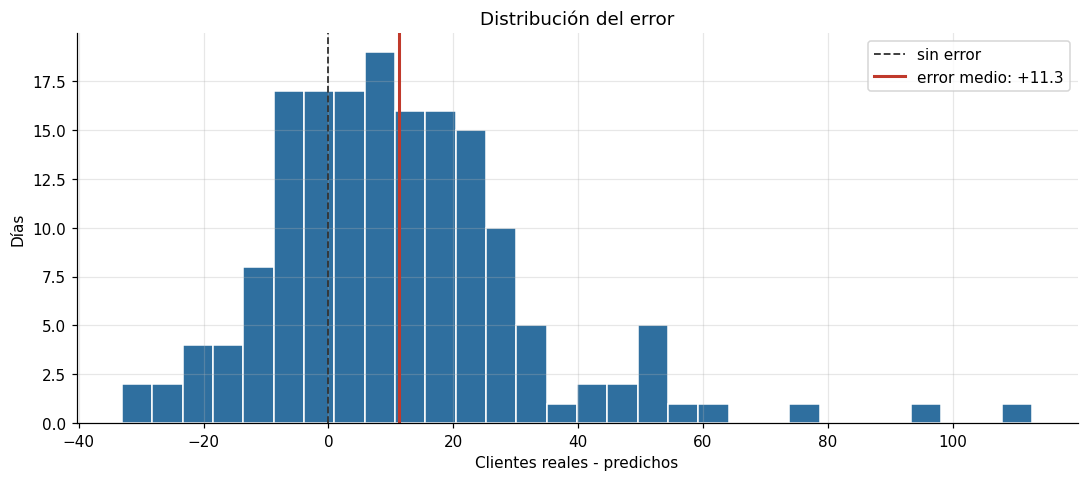

In [9]:
error_medio = test["error"].mean()
error_absoluto = test["error_absoluto"].mean()

subestimados = int((test["error"] > 0).sum())

print("SESGO DEL MODELO")
print("-" * 55)
print(f"  Error medio (real - predicho):  {error_medio:+.1f} clientes")
print(f"  Error absoluto medio:           {error_absoluto:.1f} clientes")
print(f"  Días subestimados:              {subestimados} de {len(test)} "
      f"({100 * subestimados / len(test):.0f} %)")
print()
print(f"  Proporción del error que es sesgo: {100 * abs(error_medio) / error_absoluto:.0f} %")

figura, eje = plt.subplots(figsize=(10, 4.5))

eje.hist(test["error"], bins=30, color="#2f6f9f", edgecolor="white")
eje.axvline(0, color="#333333", linestyle="--", linewidth=1.2, label="sin error")
eje.axvline(error_medio, color="#c0392b", linewidth=2,
            label=f"error medio: {error_medio:+.1f}")
eje.set_title("Distribución del error")
eje.set_xlabel("Clientes reales - predichos")
eje.set_ylabel("Días")
eje.legend()

plt.tight_layout()
plt.show()

Este es **el hallazgo más importante de la evaluación**, y también el más incómodo.

El error no es simétrico: alrededor de dos tercios de él es sesgo, no ruido. El modelo se queda corto de forma sistemática.

**La causa está en el notebook 02**: el negocio crece un 4 % al año. El modelo aprende de 2022-2024 y tiene que predecir 2026. Ninguna de las variables que usa le dice que ha pasado el tiempo, así que predice el nivel de demanda que aprendió, no el actual.

Es un problema conocido y tiene solución operativa: **reentrenar de forma periódica**. Cada vez que el modelo se reentrena con datos recientes, el sesgo se reinicia. En producción no se dejarían pasar dos años sin reentrenar.

In [10]:
print("EFECTO DE REENTRENAR CON DATOS MÁS RECIENTES")
print("-" * 60)

import json
from src.config import METADATOS_MODELOS

metadatos = json.load(open(METADATOS_MODELOS, encoding="utf-8"))

seleccion = metadatos[MODELO_PRODUCCION]
produccion = metadatos["produccion"]

print(f"  Entrenado con 2022-2024 (para elegir modelo):")
print(f"      MAE en 2026: {seleccion['metricas_test']['mae']:.2f} clientes")
print()
print(f"  Entrenado con 2022-2025 (lo que se despliega):")
print(f"      MAE en 2026: {produccion['metricas_test']['mae']:.2f} clientes")
print()

mejora = 100 * (seleccion["metricas_test"]["mae"] - produccion["metricas_test"]["mae"]) / seleccion["metricas_test"]["mae"]

print(f"  Añadir un solo año de datos recientes mejora el error un {mejora:.1f} %.")
print()
print("  2026 sigue sin usarse para entrenar en ninguno de los dos casos,")
print("  así que ambas cifras son estimaciones limpias.")

EFECTO DE REENTRENAR CON DATOS MÁS RECIENTES
------------------------------------------------------------
  Entrenado con 2022-2024 (para elegir modelo):
      MAE en 2026: 17.01 clientes

  Entrenado con 2022-2025 (lo que se despliega):
      MAE en 2026: 16.07 clientes

  Añadir un solo año de datos recientes mejora el error un 5.5 %.

  2026 sigue sin usarse para entrenar en ninguno de los dos casos,
  así que ambas cifras son estimaciones limpias.


## 5. El error por grupos

In [11]:
ORDEN = ["miércoles", "jueves", "viernes", "sábado", "domingo"]

por_dia = (
    test
    .groupby("nombre_dia")
    .agg(dias=("error", "size"),
         real=("n_clientes", "mean"),
         predicho=("prediccion", "mean"),
         error_medio=("error", "mean"),
         error_absoluto=("error_absoluto", "mean"))
    .reindex([d for d in ORDEN if d in test["nombre_dia"].unique()])
    .round(1)
)

print("ERROR POR DÍA DE LA SEMANA")
print("-" * 70)
print(por_dia.to_string())

# El error relativo es la comparación justa entre días de distinto volumen.
por_dia["error_relativo"] = (100 * por_dia["error_absoluto"] / por_dia["real"]).round(1)

print()
print("En términos ABSOLUTOS el modelo falla más los días de mucho volumen.")
print("En términos RELATIVOS la imagen cambia:")
print()
print(por_dia[["real", "error_absoluto", "error_relativo"]].to_string())

ERROR POR DÍA DE LA SEMANA
----------------------------------------------------------------------
            dias   real  predicho  error_medio  error_absoluto
nombre_dia                                                    
miércoles     32   56.7      49.1          7.6            13.3
jueves        33   76.4      68.6          7.8            13.8
viernes       33  115.2     100.6         14.5            17.5
sábado        31  159.0     144.4         14.6            21.4
domingo       31  133.0     118.5         14.5            21.1

En términos ABSOLUTOS el modelo falla más los días de mucho volumen.
En términos RELATIVOS la imagen cambia:

             real  error_absoluto  error_relativo
nombre_dia                                       
miércoles    56.7            13.3            23.5
jueves       76.4            13.8            18.1
viernes     115.2            17.5            15.2
sábado      159.0            21.4            13.5
domingo     133.0            21.1            15.9


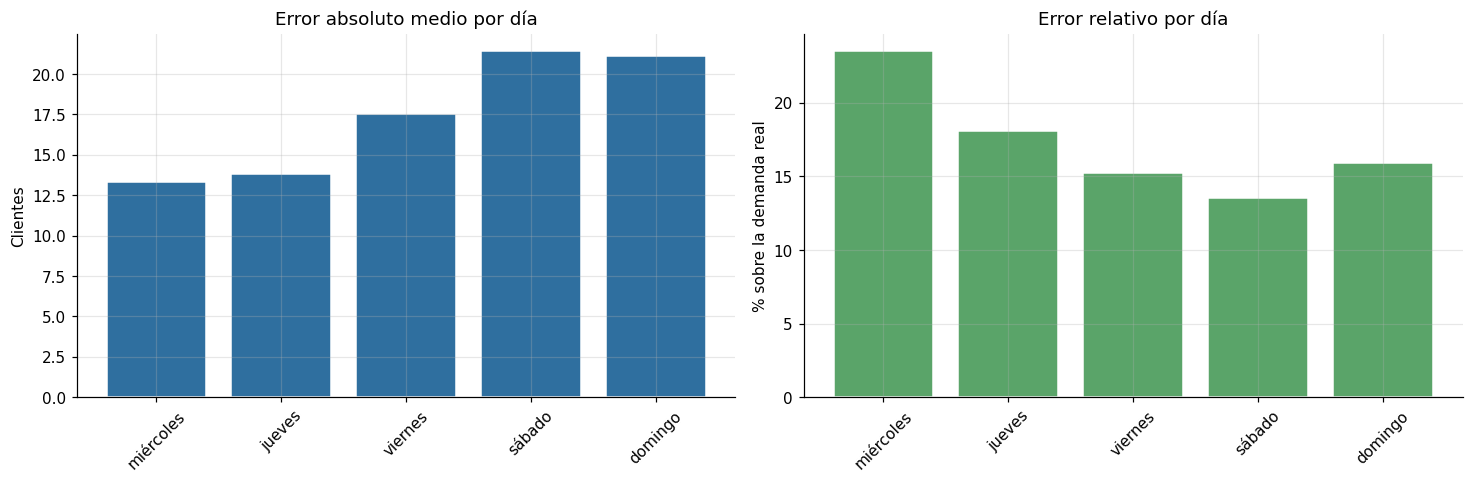

In [12]:
figura, ejes = plt.subplots(1, 2, figsize=(13.5, 4.5))

ejes[0].bar(por_dia.index, por_dia["error_absoluto"], color="#2f6f9f", edgecolor="white")
ejes[0].set_title("Error absoluto medio por día")
ejes[0].set_ylabel("Clientes")
ejes[0].tick_params(axis="x", rotation=45)

ejes[1].bar(por_dia.index, por_dia["error_relativo"], color="#5aa469", edgecolor="white")
ejes[1].set_title("Error relativo por día")
ejes[1].set_ylabel("% sobre la demanda real")
ejes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

La distinción importa para el producto: en un sábado de 200 clientes, fallar 25 es un 12 %. En un miércoles de 50, fallar 10 es un 20 %. El modelo es proporcionalmente **más fiable en los días grandes**, que son justamente los que más se juega el restaurante.

In [13]:
peores = (
    test
    .nlargest(10, "error_absoluto")[
        ["fecha", "nombre_dia", "n_clientes", "prediccion", "error", "tmax", "prec", "es_festivo"]
    ]
    .copy()
)

numericas = ["n_clientes", "prediccion", "error", "tmax", "prec"]

peores[numericas] = peores[numericas].round(1)

peores["fecha"] = peores["fecha"].dt.date

print("LOS DIEZ DÍAS CON MAYOR ERROR")
print("-" * 85)
print(peores.to_string(index=False))

LOS DIEZ DÍAS CON MAYOR ERROR
-------------------------------------------------------------------------------------
     fecha nombre_dia  n_clientes  prediccion  error  tmax  prec  es_festivo
2026-04-11     sábado         277       164.3  112.7  23.1   1.6           0
2026-07-25     sábado         253       158.6   94.4  30.4   0.0           0
2026-04-04     sábado         247       172.5   74.5  24.7   0.0           0
2026-01-09    viernes         145        82.5   62.5  14.0   0.0           0
2026-05-16     sábado         218       159.1   58.9  22.9   0.0           0
2026-04-03    viernes         181       127.5   53.5  23.3   0.0           1
2026-07-19    domingo         177       125.5   51.5  37.6   0.0           0
2026-07-26    domingo         178       127.1   50.9  33.2   0.0           0
2026-01-04    domingo         132        81.6   50.4  13.6   3.8           0
2026-04-05    domingo         194       144.0   50.0  28.1   0.0           0


## 6. ¿Qué variables usa el modelo?

Se mide con **importancia por permutación**: se desordena al azar una variable y se mira cuánto empeora el error. Si al romperla el modelo apenas se resiente, esa variable no le estaba aportando nada.

Es la única medida comparable entre modelos distintos, porque no depende de cómo funciona el algoritmo por dentro.

In [14]:
importancia = pd.read_csv(PROCESSED_RESULTADOS_DIR / "importancia_comparativa.csv", index_col=0)

print("IMPORTANCIA POR PERMUTACIÓN")
print("(aumento del error medio, en clientes, al desordenar cada variable)")
print("-" * 78)
print(importancia.round(2).to_string())

IMPORTANCIA POR PERMUTACIÓN
(aumento del error medio, en clientes, al desordenar cada variable)
------------------------------------------------------------------------------
                         Regresión lineal  Random Forest  Hist Gradient Boosting
variable_legible                                                                
dia_semana                          29.67          23.97                   27.25
mes                                  3.53           1.67                    1.98
tipo_vacaciones                      1.75           0.36                    0.62
precipitación (log)                  1.43           0.95                    1.33
temperatura media                    1.28           3.49                    6.53
amplitud térmica                     0.82           0.12                    0.04
lluvia en fin de semana              0.31           0.54                    0.18
es festivo                           0.15          -0.01                    0.11


Los tres modelos coinciden en lo esencial, y eso hace la conclusión mucho más sólida que si dependiera de un solo algoritmo:

**El día de la semana lo domina todo.** Su importancia es un orden de magnitud mayor que la de cualquier otra variable.

La meteorología aparece, pero muy por detrás. Es la confirmación cuantitativa de lo que ya apuntaba el notebook 03: el tiempo matiza la demanda, no la determina.

In [15]:
coeficientes = pd.read_csv(PROCESSED_RESULTADOS_DIR / "coeficientes_regresion_lineal.csv")

print("COEFICIENTES DE LA REGRESIÓN LINEAL")
print("(clientes que suma o resta cada variable)")
print("-" * 60)

print(
    coeficientes.head(14)[["variable_legible", "coeficiente"]]
    .round(1)
    .to_string(index=False)
)

COEFICIENTES DE LA REGRESIÓN LINEAL
(clientes que suma o resta cada variable)
------------------------------------------------------------
                variable_legible  coeficiente
        día de la semana: sábado        107.9
       día de la semana: domingo         79.7
       día de la semana: viernes         59.4
                       mes: mayo         32.2
                      mes: junio         31.7
                  mes: diciembre         29.3
        día de la semana: jueves         29.3
                    mes: octubre         23.4
                      mes: julio         20.3
tipo de vacaciones: semana_santa         20.1
                      mes: abril         18.1
                  mes: noviembre         17.6
                 mes: septiembre         15.9
        día de la semana: martes         13.1


Estos coeficientes son legibles porque se resolvió el problema de colinealidad del notebook 01. Sin esa corrección, la temperatura media tenía un coeficiente de −104 y la máxima de +58, cifras que no significan nada por separado.

Ahora se leen directamente: **un sábado trae unos 105 clientes más que un lunes**, manteniendo todo lo demás constante. Eso es algo que se puede contar en una reunión.

## Conclusiones

1. **El machine learning aporta**, pero de forma moderada: en torno a un 20-25 % de mejora sobre la media histórica por día de la semana. La mayor parte de la señal ya la capturaba el baseline.

2. **Gana la regresión lineal**, y gana de forma consistente en la validación cruzada. Es también la más interpretable y la más barata de mantener. El modelo más simple resultó ser el mejor.

3. **El modelo tiene un sesgo sistemático**: se queda corto porque no puede extrapolar el crecimiento del negocio. Está medido, documentado y avisado en la propia aplicación. Se corrige reentrenando de forma periódica.

4. **Es proporcionalmente más fiable en los días de mucho volumen**, que son los que más importan para la decisión de plantilla.

5. **El día de la semana domina sobre todo lo demás.** La meteorología influye, pero es un factor de segundo orden.

La quinta conclusión conviene decirla con claridad en la defensa: la hipótesis inicial del proyecto era que el tiempo condiciona la afluencia en hostelería. Los datos la confirman, pero también la redimensionan. Un sistema honesto tiene que reflejar eso en lugar de vender el efecto meteorológico como mayor de lo que es.